# Import Library

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from IPython.display import display

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Folder untuk menyimpan learning curve tiap model
SAVE_DIR = "learning_curves"
os.makedirs(SAVE_DIR, exist_ok=True)




NumPy: 2.5.1
Pandas: 3.0.5
Device: cpu


# Load Dataset

In [18]:
# Dataset menggunakan delimiter ';' dan baris pertama adalah judul dataset
data = pd.read_csv(
    "gsar_a_2521295_sm1572.csv",
    sep=";",
    skiprows=1,
    encoding="utf-8-sig"
)

# Buang baris dengan SMILES kosong (jika ada) & pastikan label integer
data = data.dropna(subset=["SMILES", "label"]).reset_index(drop=True)
data["label"] = data["label"].astype(int)

print(data.shape)
data[["compound ID", "SMILES", "label"]].head()

(846, 8)


,compound ID,SMILES,label
0,A001,FC1(F)CN(c2c(C(F)(F)F)cnc3[nH]c(C4=CCNC4)cc23)C1,1
1,A002,CC(C)[C@@H](NC(=O)c1cc(-c2cnn3cc(-c4ccc(OCCN5C...,1
2,A003,O=C(NCC(F)(F)F)c1cc(-c2cnc3[nH]c(C4=CCCNC4)cc3...,1
3,A004,CN1CC=C(c2cc3cc(-c4csc(C(=O)NCC(F)(F)F)c4)cnc3...,1
4,A005,O=C(NCC(F)(F)F)c1cc(-c2cnc3[nH]c(C4=CCNCC4)cc3...,1


# Tokenisasi SMILES


In [19]:
X_smiles = data["SMILES"].values

# Bangun charset dari SELURUH SMILES di dataset + token start '!' dan end 'E'
charset = set("".join(list(X_smiles)) + "!E")
char_to_int = dict((c, i) for i, c in enumerate(charset))
int_to_char = dict((i, c) for i, c in enumerate(charset))

embed = max([len(smile) for smile in X_smiles]) + 5
vocab_size = len(charset)

print("Jumlah karakter unik (vocab_size):", vocab_size)
print("Panjang embedding (embed):", embed)
print(str(charset))

Jumlah karakter unik (vocab_size): 34
Panjang embedding (embed): 102
{'s', 'n', 'O', '-', '(', '2', '3', '4', 'l', 'r', 'S', '+', 'N', '1', ')', '=', '/', 'C', '@', 'B', 'E', 'P', '#', '!', ']', '[', 'H', 'F', '5', '\\', 'I', '6', 'c', 'o'}


In [20]:
char_to_int

{'s': 0,
 'n': 1,
 'O': 2,
 '-': 3,
 '(': 4,
 '2': 5,
 '3': 6,
 '4': 7,
 'l': 8,
 'r': 9,
 'S': 10,
 '+': 11,
 'N': 12,
 '1': 13,
 ')': 14,
 '=': 15,
 '/': 16,
 'C': 17,
 '@': 18,
 'B': 19,
 'E': 20,
 'P': 21,
 '#': 22,
 '!': 23,
 ']': 24,
 '[': 25,
 'H': 26,
 'F': 27,
 '5': 28,
 '\\': 29,
 'I': 30,
 '6': 31,
 'c': 32,
 'o': 33}

# Fungsi Vectorize

In [21]:
def vectorize(smiles, charset, char_to_int, embed):
    one_hot = np.zeros((smiles.shape[0], embed, len(charset)), dtype=np.int8)
    for i, smile in enumerate(smiles):
        # encode start char
        one_hot[i, 0, char_to_int["!"]] = 1
        # encode karakter SMILES
        for j, c in enumerate(smile):
            if c in char_to_int:
                one_hot[i, j + 1, char_to_int[c]] = 1
        # encode end char (padding sisa)
        one_hot[i, len(smile) + 1:, char_to_int["E"]] = 1
    return one_hot[:, 0:-1, :]

# Vectorize SELURUH dataset (tanpa split)
X_onehot = vectorize(X_smiles, charset, char_to_int, embed)

# Ubah one-hot menjadi integer sequence (siap untuk Embedding layer nantinya)
X_encoded = np.argmax(X_onehot, axis=2)

# Visual Hasil Encoding SMILES

In [22]:
print("vocab_size:", vocab_size, "| embed:", embed)
print("X_onehot shape :", X_onehot.shape)   # (jumlah_senyawa, panjang_sequence, jumlah_karakter_unik)
print("X_encoded shape:", X_encoded.shape)  # (jumlah_senyawa, panjang_sequence)

idx = 0  # ganti index sesuai molekul yang ingin dilihat

print("\nSMILES asli:", X_smiles[idx])
print()
print("One-hot encoding, 10 posisi pertama:")
print(X_onehot[idx][:10])

print("Integer-encoded, 20 posisi pertama:")
print(X_encoded[idx][:20])

decoded = "".join([int_to_char[i] for i in X_encoded[idx]])
print("Hasil decode balik:", decoded)

vocab_size: 34 | embed: 102
X_onehot shape : (846, 101, 34)
X_encoded shape: (846, 101)

SMILES asli: FC1(F)CN(c2c(C(F)(F)F)cnc3[nH]c(C4=CCNC4)cc23)C1

One-hot encoding, 10 posisi pertama:
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]
Integer-encoded, 20 posisi pertama:
[23 27 17 13  4 27 14 17 12  4 32  5 32  4 17  4 27 14  4 27]
Ha

# Penggabungan Hasil Encoding SMILES dengan Label

In [23]:
y = data["label"].values

print("X_encoded shape:", X_encoded.shape)
print("y shape         :", y.shape)

# Validasi
assert X_encoded.shape[0] == y.shape[0], "Jumlah baris SMILES dan label tidak sinkron!"

X_encoded shape: (846, 101)
y shape         : (846,)


# Split Train/Test

In [24]:
X = X_encoded          
y_arr = y.reshape(-1, 1) if y.ndim == 1 else y

X_train, X_test, Y_train, Y_test = train_test_split(
    X, y_arr,
    test_size=0.3,
    random_state=42,
    stratify=y_arr
)

print(X_train.shape, X_test.shape)

(592, 101) (254, 101)


# Dataset & Dataset Loader

In [25]:
class SmilesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = SmilesDataset(X_train, Y_train)
test_dataset  = SmilesDataset(X_test, Y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Pembentukan model Baseline

In [26]:
class LSTMBaseline(nn.Module):
    def __init__(self, vocab_size, embedding_dim=50, units_list=[64]):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm_layers = nn.ModuleList()
        input_size = embedding_dim
        for units in units_list:
            self.lstm_layers.append(nn.LSTM(input_size=input_size, hidden_size=units, batch_first=True))
            input_size = units
        self.output_layer = nn.Linear(units_list[-1], 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out = self.embedding(x)
        for lstm in self.lstm_layers:
            out, _ = lstm(out)
        out = out[:, -1, :]
        out = self.output_layer(out)
        return self.sigmoid(out)


def train_model(model, train_loader, test_loader, epochs=50, lr=0.001, device=device):
    model.to(device)
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * xb.size(0)
            train_correct += ((preds > 0.5).float() == yb).sum().item()
            train_total += xb.size(0)

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                loss = criterion(preds, yb)
                val_loss += loss.item() * xb.size(0)
                val_correct += ((preds > 0.5).float() == yb).sum().item()
                val_total += xb.size(0)

        history["loss"].append(train_loss / train_total)
        history["accuracy"].append(train_correct / train_total)
        history["val_loss"].append(val_loss / val_total)
        history["val_accuracy"].append(val_correct / val_total)

        print(f"Epoch {epoch+1}/{epochs} - loss: {history['loss'][-1]:.4f} - acc: {history['accuracy'][-1]:.4f} "
              f"- val_loss: {history['val_loss'][-1]:.4f} - val_acc: {history['val_accuracy'][-1]:.4f}")

    return history


def get_predictions(model, data_loader, device=device, threshold=0.5):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for xb, yb in data_loader:
            xb = xb.to(device)
            probs = model(xb).cpu().numpy().flatten()
            preds = (probs >= threshold).astype(int)
            y_true.extend(yb.numpy().flatten().astype(int))
            y_pred.extend(preds)
    return np.array(y_true), np.array(y_pred)


def compute_confusion_matrix(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    return TP, TN, FP, FN


def compute_metrics(TP, TN, FP, FN, eps=1e-10):
    accuracy  = (TP + TN) / (TP + TN + FP + FN + eps)
    recall    = TP / (TP + FN + eps)
    precision = TP / (TP + FP + eps)
    f1_score  = 2 * (precision * recall) / (precision + recall + eps)
    return {"accuracy": accuracy, "recall": recall, "precision": precision, "f1_score": f1_score}


def plot_confusion_matrix_image(TP, TN, FP, FN, model_name="", dataset_name=""):
    cm = np.array([[TP, FN],
                   [FP, TN]])

    fig, ax = plt.subplots(figsize=(5, 4.5))
    im = ax.imshow(cm, cmap="Blues")

    # Label sumbu
    labels = ["Aktif (1)", "Inaktif (0)"]
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Kelas Prediksi")
    ax.set_ylabel("Kelas Aktual")
    ax.set_title(f"Confusion Matrix - {model_name} ({dataset_name})")

    # Tulis angka di tiap sel
    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], "d"),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black",
                     fontsize=14, fontweight="bold")

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

def evaluate_on_loader(model, loader, model_name="", dataset_name=""):
    y_true, y_pred = get_predictions(model, loader)
    TP, TN, FP, FN = compute_confusion_matrix(y_true, y_pred)
    metrics = compute_metrics(TP, TN, FP, FN)

    plot_confusion_matrix_image(TP, TN, FP, FN, model_name=model_name, dataset_name=dataset_name)

    print(f"Accuracy  : {metrics['accuracy']:.4f}")
    print(f"Recall    : {metrics['recall']:.4f}")
    print(f"Precision : {metrics['precision']:.4f}")
    print(f"F1-Score  : {metrics['f1_score']:.4f}")

    return {"TP": TP, "TN": TN, "FP": FP, "FN": FN, **metrics}


def plot_and_save_learning_curve(history, model_name, save_dir=SAVE_DIR):
    """Plot learning curve (loss & accuracy, train vs val) lalu simpan ke file PNG."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    axes[0].plot(history["loss"], label="Training Loss")
    axes[0].plot(history["val_loss"], label="Testing Loss")
    axes[0].set_title(f"Loss Curve - {model_name}")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    # Accuracy
    axes[1].plot(history["accuracy"], label="Training Accuracy")
    axes[1].plot(history["val_accuracy"], label="Testing Accuracy")
    axes[1].set_title(f"Accuracy Curve - {model_name}")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()

    save_path = os.path.join(save_dir, f"learning_curve_{model_name.replace(' ', '_')}.png")
    plt.savefig(save_path, dpi=150)
    print(f"Learning curve disimpan di: {save_path}")

    plt.show()

# Baseline 1

In [27]:
print("="*60)
print("BASELINE 1 | LSTM layers: [64]")
print("="*60)

model_b1 = LSTMBaseline(vocab_size=vocab_size, embedding_dim=50, units_list=[64])
print(model_b1)

history_b1 = train_model(model_b1, train_loader, test_loader, epochs=50, lr=0.001)

BASELINE 1 | LSTM layers: [64]
LSTMBaseline(
  (embedding): Embedding(34, 50)
  (lstm_layers): ModuleList(
    (0): LSTM(50, 64, batch_first=True)
  )
  (output_layer): Linear(in_features=64, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)
Epoch 1/50 - loss: 0.7014 - acc: 0.4747 - val_loss: 0.6931 - val_acc: 0.5039
Epoch 2/50 - loss: 0.6956 - acc: 0.5017 - val_loss: 0.6930 - val_acc: 0.5157
Epoch 3/50 - loss: 0.6945 - acc: 0.4628 - val_loss: 0.6939 - val_acc: 0.4961
Epoch 4/50 - loss: 0.6937 - acc: 0.4983 - val_loss: 0.6928 - val_acc: 0.4961
Epoch 5/50 - loss: 0.6921 - acc: 0.5068 - val_loss: 0.6839 - val_acc: 0.6614
Epoch 6/50 - loss: 0.6591 - acc: 0.7179 - val_loss: 0.6336 - val_acc: 0.6929
Epoch 7/50 - loss: 0.5627 - acc: 0.7466 - val_loss: 0.5501 - val_acc: 0.6457
Epoch 8/50 - loss: 0.4403 - acc: 0.8260 - val_loss: 0.3965 - val_acc: 0.8622


KeyboardInterrupt: 

Learning curve disimpan di: learning_curves\learning_curve_Baseline_1.png


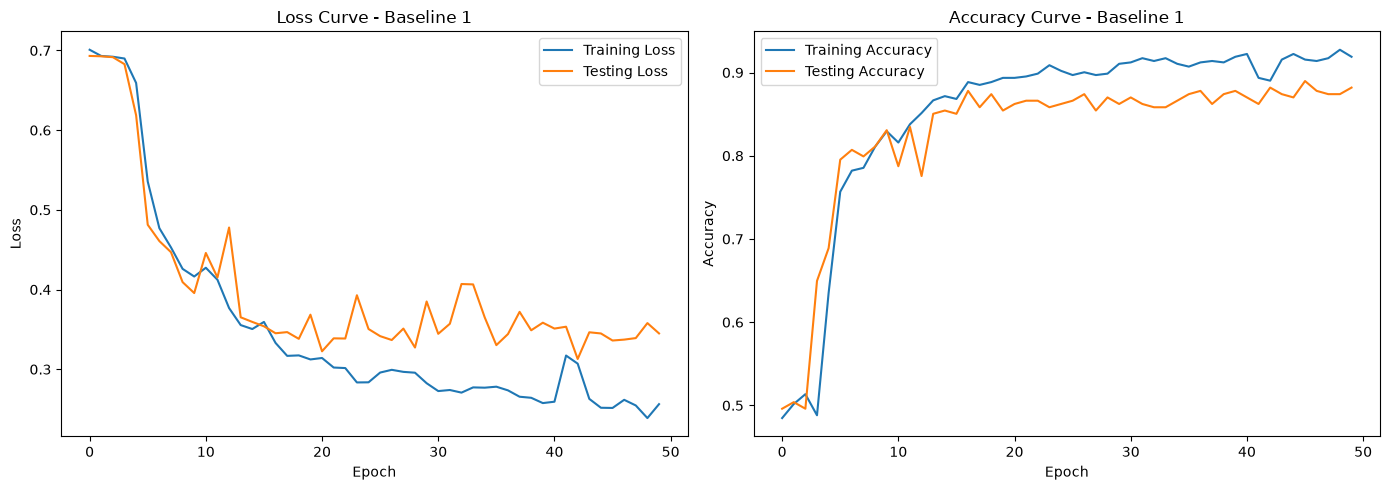

In [ ]:
# Learning curve (loss & accuracy, train vs test) - disimpan ke file
plot_and_save_learning_curve(history_b1, model_name="Baseline 1")

In [ ]:
# Nilai akhir training vs testing (epoch terakhir)
print("=== Ringkasan Nilai Akhir - Baseline 1 ===")
print(f"Training Loss     : {history_b1['loss'][-1]:.4f} | Training Accuracy : {history_b1['accuracy'][-1]:.4f}")
print(f"Testing  Loss     : {history_b1['val_loss'][-1]:.4f} | Testing  Accuracy : {history_b1['val_accuracy'][-1]:.4f}")

=== Ringkasan Nilai Akhir - Baseline 1 ===
Training Loss     : 0.2562 | Training Accuracy : 0.9189
Testing  Loss     : 0.3450 | Testing  Accuracy : 0.8819


In [ ]:
# Evaluasi Confusion Matrix + Metrik pada DATA TRAIN
print("\n>>> Evaluasi pada DATA TRAIN <<<")
train_metrics_b1 = evaluate_on_loader(model_b1, train_loader, model_name="Baseline 1", dataset_name="Train")


>>> Evaluasi pada DATA TRAIN <<<

Confusion Matrix - Baseline 1 (Train)
                    Prediksi Aktif (1)  Prediksi Inaktif (0)
Aktual Aktif (1)                   264                    31
Aktual Inaktif (0)                  15                   282
Accuracy  : 0.9223
Recall    : 0.8949
Precision : 0.9462
F1-Score  : 0.9199


In [ ]:
# Evaluasi Confusion Matrix + Metrik pada DATA TEST
print("\n>>> Evaluasi pada DATA TEST <<<")
test_metrics_b1 = evaluate_on_loader(model_b1, test_loader, model_name="Baseline 1", dataset_name="Test")


>>> Evaluasi pada DATA TEST <<<

Confusion Matrix - Baseline 1 (Test)
                    Prediksi Aktif (1)  Prediksi Inaktif (0)
Aktual Aktif (1)                   107                    19
Aktual Inaktif (0)                  11                   117
Accuracy  : 0.8819
Recall    : 0.8492
Precision : 0.9068
F1-Score  : 0.8770


# BAseline 2

In [ ]:
print("="*60)
print("BASELINE 2 | LSTM layers: [64, 128]")
print("="*60)

model_b2 = LSTMBaseline(vocab_size=vocab_size, embedding_dim=50, units_list=[64, 128])
print(model_b2)

history_b2 = train_model(model_b2, train_loader, test_loader, epochs=50, lr=0.001)

BASELINE 2 | LSTM layers: [64, 128]
LSTMBaseline(
  (embedding): Embedding(34, 50)
  (lstm_layers): ModuleList(
    (0): LSTM(50, 64, batch_first=True)
    (1): LSTM(64, 128, batch_first=True)
  )
  (output_layer): Linear(in_features=128, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)
Epoch 1/50 - loss: 0.6946 - acc: 0.4696 - val_loss: 0.6929 - val_acc: 0.5197
Epoch 2/50 - loss: 0.6934 - acc: 0.5236 - val_loss: 0.6927 - val_acc: 0.5157
Epoch 3/50 - loss: 0.6919 - acc: 0.5338 - val_loss: 0.6883 - val_acc: 0.4961
Epoch 4/50 - loss: 0.6018 - acc: 0.6774 - val_loss: 0.5711 - val_acc: 0.7047
Epoch 5/50 - loss: 0.5051 - acc: 0.7551 - val_loss: 0.5560 - val_acc: 0.6890
Epoch 6/50 - loss: 0.4608 - acc: 0.7821 - val_loss: 0.4403 - val_acc: 0.7913
Epoch 7/50 - loss: 0.4613 - acc: 0.7838 - val_loss: 0.4940 - val_acc: 0.7992
Epoch 8/50 - loss: 0.4534 - acc: 0.7872 - val_loss: 0.4312 - val_acc: 0.7913
Epoch 9/50 - loss: 0.4414 - acc: 0.7905 - val_loss: 0.4239 - val_acc: 0.8031
Epoch 10/50 - lo

KeyboardInterrupt: 

In [ ]:
plot_and_save_learning_curve(history_b2, model_name="Baseline 2")

In [ ]:
print("=== Ringkasan Nilai Akhir - Baseline 2 ===")
print(f"Training Loss     : {history_b2['loss'][-1]:.4f} | Training Accuracy : {history_b2['accuracy'][-1]:.4f}")
print(f"Testing  Loss     : {history_b2['val_loss'][-1]:.4f} | Testing  Accuracy : {history_b2['val_accuracy'][-1]:.4f}")

In [ ]:
print("\n>>> Evaluasi pada DATA TRAIN <<<")
train_metrics_b2 = evaluate_on_loader(model_b2, train_loader, model_name="Baseline 2", dataset_name="Train")

In [ ]:
print("\n>>> Evaluasi pada DATA TEST <<<")
test_metrics_b2 = evaluate_on_loader(model_b2, test_loader, model_name="Baseline 2", dataset_name="Test")

# Baseline 3

In [ ]:
print("="*60)
print("BASELINE 3 | LSTM layers: [64, 128, 256]")
print("="*60)

model_b3 = LSTMBaseline(vocab_size=vocab_size, embedding_dim=50, units_list=[64, 128, 256])
print(model_b3)

history_b3 = train_model(model_b3, train_loader, test_loader, epochs=50, lr=0.001)

In [ ]:
plot_and_save_learning_curve(history_b3, model_name="Baseline 3")

In [ ]:
print("\n>>> Evaluasi pada DATA TRAIN <<<")
train_metrics_b3 = evaluate_on_loader(model_b3, train_loader, model_name="Baseline 3", dataset_name="Train")

In [ ]:
print("\n>>> Evaluasi pada DATA TEST <<<")
test_metrics_b3 = evaluate_on_loader(model_b3, test_loader, model_name="Baseline 3", dataset_name="Test")

# Penggabungan Hasil ke 1 Dataframe

In [ ]:
# Kumpulkan hasil train dan test tiap baseline
train_results = {
    "Baseline 1": train_metrics_b1,
    "Baseline 2": train_metrics_b2,
    "Baseline 3": train_metrics_b3,
}
test_results = {
    "Baseline 1": test_metrics_b1,
    "Baseline 2": test_metrics_b2,
    "Baseline 3": test_metrics_b3,
}

cols = ["TP", "TN", "FP", "FN", "accuracy", "recall", "precision", "f1_score"]

train_summary_df = pd.DataFrame(train_results).T[cols]
test_summary_df  = pd.DataFrame(test_results).T[cols]

print("=== Ringkasan Metrik - DATA TRAIN ===")
display(train_summary_df)

print("\n=== Ringkasan Metrik - DATA TEST ===")
display(test_summary_df)

# SUMMary

In [ ]:
# Gabungan Train vs Test dalam SATU dataframe (multi-level column: Train | Test)
combined_summary_df = pd.concat(
    {"Train": train_summary_df, "Test": test_summary_df},
    axis=1
)

display(combined_summary_df)

In [ ]:
# Ringkasan learning curve (loss & accuracy akhir) ketiga baseline dalam satu tabel
histories = {"Baseline 1": history_b1, "Baseline 2": history_b2, "Baseline 3": history_b3}

training_summary_df = pd.DataFrame({
    name: {
        "train_loss": hist["loss"][-1],
        "train_acc": hist["accuracy"][-1],
        "test_loss": hist["val_loss"][-1],
        "test_acc": hist["val_accuracy"][-1],
    }
    for name, hist in histories.items()
}).T

display(training_summary_df)